# LSTM for ETF Cross-Asset Momentum

The LSTM asks whether learned temporal state adds anything to the engineered lookback features
the earlier stages already hand every model. It reads each fund's feature history as a sequence
rather than as a row, so if there is structure in the *order* of observations that a flat feature
vector cannot express, this is the family that should find it.

**Learning objectives**
- Declare a sequence population and resolve it against the data before any fitting happens
- Tune the epoch checkpoint on the validation folds without reading the holdout, under a
  full-coverage guard that excludes checkpoints whose predictions collapsed on some folds
- Place the result against the linear and gradient-boosting leaders on the same cross-section

**Book reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb), which fit the
populations this one is compared against.

In [1]:
"""Fit the declared ETF sequence population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display

from case_studies.research import (
    Result,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.registry import load_prediction_metrics
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "etfs"
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    CASE_STUDY_ID,
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="09_dl_lstm",
)
PRIMARY_LABEL = primary_label(study)

## 1. Which models, and on what

The training menu declares the whole `deep_learning` family for this case study. This notebook
fits the recurrent member of it; [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) fits the mixer, which
runs on a different backend and is separated for that reason rather than for a modelling one.

**The menu declares a third architecture, `nlinear`, that no notebook fits.** It is left
unfitted here rather than quietly added: fitting it would widen the published population inside a
migration commit, and a configuration declared and never fitted is a finding rather than a
detail. It is why this run names its own population instead of publishing the family's.

In [4]:
SEQUENCE_CONFIGS = ("lstm_h64",)
declared = load_model_configs(study, "deep_learning", config_names=list(SEQUENCE_CONFIGS))
configs = load_model_configs(
    study,
    "deep_learning",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or list(SEQUENCE_CONFIGS),
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""deep_learning""","""fwd_ret_21d""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"
"""deep_learning""","""fwd_ret_5d""","""lstm_h64""","""""","""architecture=lstm, dropout=0.1…"


`LABELS` and `CONFIG_NAMES` narrow the run below this notebook's own slice, and a narrowed run
declares a different set of members than the published population does. A population is immutable
once written, so such a run has to publish under its own name: on a fresh workspace it would
otherwise freeze an incomplete snapshot under the published one, and where that population
already exists the registry refuses the write outright. The comparison is over
label-configuration pairs rather than row counts, because two different subsets can have the
same height.

The device is checked in the same place and for the same reason. A network trained on a GPU and
the same network trained on a CPU accumulate their sums in a different order and reach different
weights, so the device is part of what the fitted model *is*. It sits inside the hashed identity
rather than beside it, and the runner refuses to substitute a CPU for a requested GPU rather than
publish a different model under the published name. On a machine with no NVIDIA card this
notebook therefore stops at the next cell; set `DEVICE="cpu"` and pass a `POPULATION_NAME` to fit
the same grid there.

In [5]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

narrows = set(zip(configs["label"], configs["config_name"], strict=True)) != set(
    zip(declared["label"], declared["config_name"], strict=True)
)
if (narrows or device != PUBLISHED_DEVICE) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not this notebook's declared slice on {PUBLISHED_DEVICE!r}, so it cannot "
        "publish the sequence population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. The baselines this is measured against

Read back from the registry rather than re-fitted here. Each is its family's full-coverage
validation leader, so all three numbers in the family comparison below are measured over the
same validation dates on the same cross-section.

In [6]:
prior_baselines = {}
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
for row in _baselines.iter_rows(named=True):
    # The full-coverage linear leader is a Ridge configuration; name it plainly so the comparison
    # below resolves it.
    if row["family"] == "linear":
        prior_baselines["Ridge (Ch11)"] = row["ic_mean"]
    elif row["family"] == "gbm":
        prior_baselines["GBM (Ch12)"] = row["ic_mean"]

if prior_baselines:
    for name, ic in prior_baselines.items():
        print(f"  {name}: IC={ic:+.4f}" if ic is not None else f"  {name}: IC=n/a")
else:
    print("  No prior results registered - run 06_linear and 07_gbm first")

  GBM (Ch12): IC=+0.0746
  Ridge (Ch11): IC=+0.0469


## 3. Binding the declaration to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, which fund-date pairs have both a feature row and a label, or - for
a sequence model - which of those pairs have a full unbroken window of prior observations behind
them. **Resolving** the request goes and finds all of it.

Resolving reads the inputs and fits nothing, so the plan can be read before any GPU time is
spent. Four things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of a label.**
  They are the width of the design matrix, the number of funds, and the number of fund-date pairs
  to be predicted. A row that differs is a configuration measured on a different sample from its
  neighbours, and its result is not comparable with theirs.
- **`eligible_rows` is below what a flat-feature family reports on the same label.** A sequence
  prediction needs a gap-free window behind it, so what drops out is a fund too new to have
  accumulated one, or a stretch where the calendar has a hole inside the window. That is why a
  sequence result and a tabular result on the same label are measurements on different samples,
  which `full_coverage` marks within this family and
  [`13_model_analysis`](13_model_analysis.ipynb) has to account for across families.
- **`folds` is the same everywhere** and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: any of it visible in this window would mean it had been used to choose
  something.

Each row also carries a `training_hash`, the identity of that computation, derived from
everything that can change its result - the device and the lookback included.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_21d""","""lstm_h64""",71,99,187633,8,20,2015-12-28 00:00:00,2023-11-29 00:00:00
"""fwd_ret_5d""","""lstm_h64""",71,99,189169,8,20,2015-12-28 00:00:00,2023-12-21 00:00:00


## 4. Fitting the population

`run_model_population` fits every resolved request: for one request it walks the folds, saves a
checkpoint at each declared epoch interval, scores each checkpoint on that fold's validation
dates, and registers every checkpoint as its own prediction set. What the call publishes is a
**population** - a named, immutable list of the prediction sets it produced - which is what
[`14_backtest`](14_backtest.ipynb) resolves rather than a query it composes itself.

**There is one identity builder, and the runner owns it.** The previous version of this notebook
built its own lookup specification to decide whether a configuration was already fitted, and that
specification had to agree field for field with the one the runner registered under. It stopped
agreeing when the device became identity-bearing, and the failure was not a wasted cache lookup:
the model trained, registered under the fuller identity, and the notebook then reported its own
checkpoints incomplete. Nothing here derives an identity any more, so nothing here can disagree.

**A second run fits nothing.** Every identity is re-derived from the inputs, the registry already
holds the matching rows and the saved weights, and `reused` in the line below counts what came
back from store rather than from a GPU.

`SUPERSEDES_POPULATION` names the population hash this run replaces. It is empty here because
this run publishes a name nothing has published before; a later refit under changed code produces
a different member set, and the registry refuses the write until it is told which snapshot it
retires.

In [8]:
population_name = POPULATION_NAME or "etfs-lstm-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Fold-major CV: 8 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=221,577 seq across 99 symbols
    val=22,114 seq across 96 symbols
    creating datasets...
    datasets ready
    lstm_h64:


      epoch   1/100: train_loss=0.003259


      epoch   2/100: train_loss=0.001975


      epoch   3/100: train_loss=0.001524


...

      epoch 100/100: train_loss=0.000207, val_loss=0.001228, IC=-0.0231


      best_ep=10, IC=+0.0239 (526.3s, 20 checkpoints)


  lstm_h64: best_epoch=10, IC=-0.0045 (5852.2s)



  Best: lstm_h64 @ epoch 10 (IC=-0.0045)
  Saved to ~/ml4t/public-s6-etfs/case_studies/etfs/run_log/training/6d830496782c/diagnostics


2 configurations: 2 trained, 0 read
population etfs-lstm-validation-v1: 40 prediction sets


## 5. What came out, and which checkpoints are comparable

One row per epoch checkpoint. The **information coefficient** is the daily one: on each
validation date, rank the funds by the model's prediction, rank them by the return they went on
to earn, correlate the two rankings, and average that daily correlation over the validation
period. Zero is no relationship.

**The daily IC is read from `prediction_metrics` rather than from the catalog, and that is not a
stylistic choice.** The research catalog exposes `ic_mean` and `ic_n_days` side by side, but they
do not describe the same quantity: `ic_mean` is the mean over folds, while `ic_n_days` counts the
dates behind `ic_mean_daily`, which the catalog does not carry. Pairing the two that the catalog
offers reports a coverage count for a statistic it was not computed from. Until the catalog
carries the daily IC, this cell reads it where it lives.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which
rows are comparable with each other. A network that has settled into predicting nearly the same
value for every fund on a date gives that date no spread to rank, and the date drops out of the
average - which makes a collapsed checkpoint look better by being scored on fewer, easier days.
`full_coverage` marks the checkpoints measured on every date the label offers, and selection
happens only among those.

In [9]:
_daily = pl.concat(
    [
        load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash).select(
            "prediction_hash", "ic_mean_daily", "ic_n_days"
        )
        for prediction_hash in execution.catalog_rows["prediction_hash"].to_list()
    ]
)
checkpoints = (
    execution.catalog_rows.select(
        "config_name", "label", "complete", "checkpoint_value", "n_folds", "prediction_hash"
    )
    .join(_daily, on="prediction_hash", how="inner")
    .filter(pl.col("label") == PRIMARY_LABEL)
    .with_columns(
        (pl.col("ic_n_days") == pl.col("ic_n_days").max().over("config_name")).alias(
            "full_coverage"
        )
    )
    .sort("checkpoint_value")
)
if checkpoints.is_empty():
    raise RuntimeError(f"no registered checkpoints for {CASE_STUDY_ID}/{PRIMARY_LABEL}")
if not checkpoints["complete"].all():
    raise RuntimeError("an incomplete checkpoint is registered; the population cannot be read")

The selection rule is the sequence-model analogue of early stopping: scan the checkpoint grid on
the validation folds and keep the highest-IC checkpoint among those with full coverage. The
holdout is not touched.

In [10]:
eligible = checkpoints.filter("full_coverage")
best_row = eligible.sort("ic_mean_daily", descending=True).row(0, named=True)
BEST_EPOCH = int(best_row["checkpoint_value"])
BEST_IC = float(best_row["ic_mean_daily"])
BEST_NAME = best_row["config_name"]
BEST_PHASH = best_row["prediction_hash"]
FULL_DAYS = float(best_row["ic_n_days"])
partial_epochs = (
    checkpoints.filter(~pl.col("full_coverage"))["checkpoint_value"].cast(pl.Int64).to_list()
)

print(f"Config: {BEST_NAME}   full-coverage validation days = {int(FULL_DAYS)}")
print(checkpoints.select("checkpoint_value", "ic_mean_daily", "ic_n_days", "full_coverage"))
print(f"\nFull-coverage winner: {BEST_NAME} @ epoch {BEST_EPOCH} (IC={BEST_IC:+.4f})")
if partial_epochs:
    print(f"Excluded before selection, partial coverage: epochs {partial_epochs}")

Config: lstm_h64   full-coverage validation days = 1995
shape: (20, 4)
┌──────────────────┬───────────────┬───────────┬───────────────┐
│ checkpoint_value ┆ ic_mean_daily ┆ ic_n_days ┆ full_coverage │
│ ---              ┆ ---           ┆ ---       ┆ ---           │
│ i64              ┆ f64           ┆ f64       ┆ bool          │
╞══════════════════╪═══════════════╪═══════════╪═══════════════╡
│ 5                ┆ -0.009876     ┆ 1995.0    ┆ true          │
│ 10               ┆ -0.001169     ┆ 1995.0    ┆ true          │
│ 15               ┆ 0.006293      ┆ 1995.0    ┆ true          │
│ 20               ┆ 0.002636      ┆ 1995.0    ┆ true          │
│ 25               ┆ -0.000207     ┆ 1995.0    ┆ true          │
│ …                ┆ …             ┆ …         ┆ …             │
│ 80               ┆ 0.01946       ┆ 1995.0    ┆ true          │
│ 85               ┆ 0.01753       ┆ 1995.0    ┆ true          │
│ 90               ┆ 0.018949      ┆ 1995.0    ┆ true          │
│ 95               

## 6. The learning curve

Validation IC at each epoch checkpoint. The selected checkpoint is amber; any checkpoint excluded
for partial coverage is copper. A curve that rises and then falls is the model fitting and then
overfitting the validation folds; a flat one says the epoch count was never the binding choice.

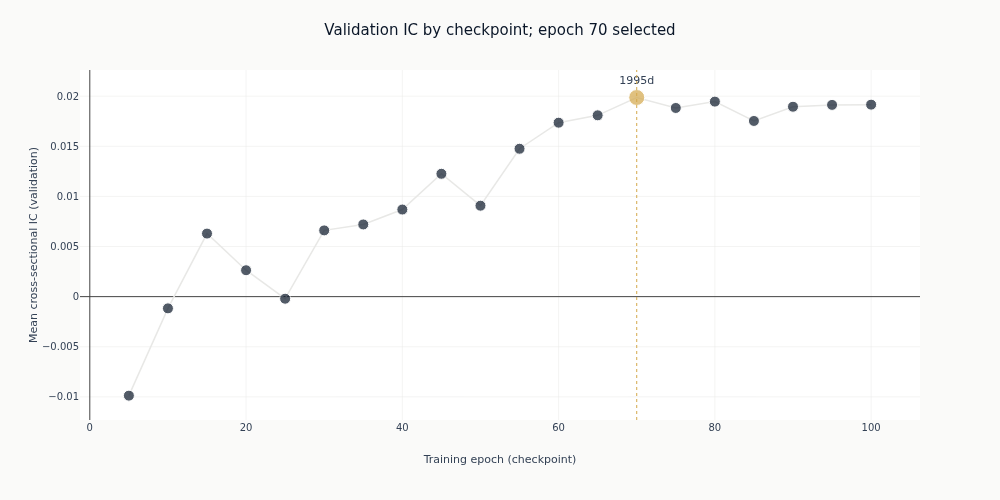

In [11]:
_epochs = checkpoints["checkpoint_value"].cast(pl.Int64).to_list()
_ics = checkpoints["ic_mean_daily"].to_list()
_days = checkpoints["ic_n_days"].to_list()
_colors = [
    COLORS["amber"]
    if epoch == BEST_EPOCH
    else (COLORS["copper"] if epoch in partial_epochs else COLORS["blue"])
    for epoch in _epochs
]
fig_lc = go.Figure(
    go.Scatter(
        x=_epochs,
        y=_ics,
        mode="lines+markers+text",
        line=dict(color=COLORS["silver_muted"], width=1.5),
        marker=dict(
            color=_colors,
            size=[16 if epoch == BEST_EPOCH else 11 for epoch in _epochs],
            line=dict(color="white", width=1),
        ),
        text=[
            f"{days:.0f}d" if epoch == BEST_EPOCH or days < FULL_DAYS else ""
            for epoch, days in zip(_epochs, _days, strict=True)
        ],
        textposition="top center",
        showlegend=False,
    )
)
fig_lc.add_vline(x=BEST_EPOCH, line=dict(color=COLORS["amber"], width=1, dash="dot"))
fig_lc.update_layout(
    title=(
        f"Validation IC by checkpoint; epoch {BEST_EPOCH} selected"
        + (f", partial epochs {partial_epochs} excluded" if partial_epochs else "")
    ),
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
fig_lc.show()

## 7. Against the flat-feature baselines

The selected checkpoint against the linear and gradient-boosting leaders, all three on the same
label and the same validation split. This is the comparison the notebook exists to make: whether
reading the history as a sequence adds anything over handing the same history to a model as
columns.

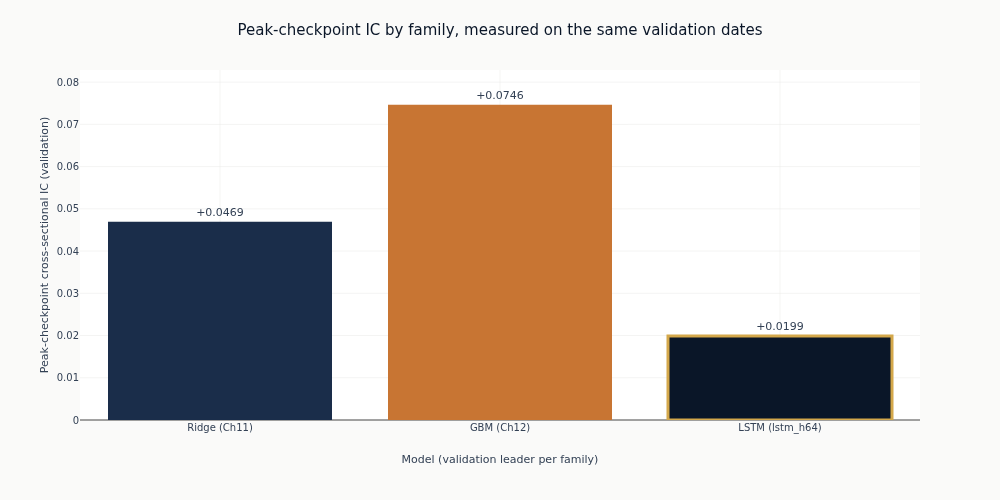

In [12]:
ridge_ic = prior_baselines.get("Ridge (Ch11)", float("nan"))
gbm_ic = prior_baselines.get("GBM (Ch12)", float("nan"))

_labels = ["Ridge (Ch11)", "GBM (Ch12)", f"LSTM ({BEST_NAME})"]
_vals = [ridge_ic, gbm_ic, BEST_IC]
fig_cmp = go.Figure(
    go.Bar(
        x=_labels,
        y=_vals,
        marker=dict(
            color=[COLORS["slate"], COLORS["copper"], COLORS["blue"]],
            line=dict(color=COLORS["amber"], width=[0, 0, 3]),
        ),
        text=[f"{value:+.4f}" for value in _vals],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
fig_cmp.update_layout(
    title="Peak-checkpoint IC by family, measured on the same validation dates",
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_cmp.update_xaxes(title_text="Model (validation leader per family)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

## 8. Is the average stable across time?

The reported IC is an average over folds, and an average can be positive while most of its terms
are not. The per-fold breakdown is what separates a model with a weak but consistent edge from
one whose mean is carried by a single fold.

In [13]:
folds = Result.open(study, BEST_PHASH).folds().select("fold_id", "ic", "n_entities").sort("fold_id")
print(f"Per-fold validation IC ({BEST_NAME} @ epoch {BEST_EPOCH}):")
print(folds)
NEGATIVE_FOLDS = int(folds.filter(pl.col("ic") < 0).height)
print(f"\n  Folds with negative IC: {NEGATIVE_FOLDS} of {folds.height}")
print(f"  Winner prediction_hash: {BEST_PHASH}")

Per-fold validation IC (lstm_h64 @ epoch 70):
shape: (8, 3)
┌─────────┬───────────┬────────────┐
│ fold_id ┆ ic        ┆ n_entities │
│ ---     ┆ ---       ┆ ---        │
│ i64     ┆ f64       ┆ f64        │
╞═════════╪═══════════╪════════════╡
│ 0       ┆ 0.102586  ┆ 96.0       │
│ 1       ┆ 0.049181  ┆ 97.0       │
│ 2       ┆ -0.025124 ┆ 96.0       │
│ 3       ┆ -0.004468 ┆ 97.0       │
│ 4       ┆ 0.07584   ┆ 97.0       │
│ 5       ┆ 0.017883  ┆ 96.0       │
│ 6       ┆ -0.018756 ┆ 95.0       │
│ 7       ┆ -0.031287 ┆ 90.0       │
└─────────┴───────────┴────────────┘

  Folds with negative IC: 4 of 8
  Winner prediction_hash: e929d59ae011


## 9. What to notice

In [14]:
_coverage_text = (
    f"All {checkpoints.height} checkpoints cover {FULL_DAYS:.0f} validation dates."
    if not partial_epochs
    else f"Checkpoints at epochs {partial_epochs} were excluded before selection."
)
display(
    Markdown(
        f"""
- **The sequence model is measured against the flat-feature families on the same dates.** The
  checkpoint it selects is epoch **{BEST_EPOCH}** at validation IC **{BEST_IC:+.3f}**, against
  Ridge **{ridge_ic:+.3f}** and GBM **{gbm_ic:+.3f}**.
- **Coverage is comparable across the checkpoint choice.** {_coverage_text} The guard stays
  necessary either way: a collapsed checkpoint scores on fewer dates and can look better for it.
- **The average is not the whole story.** The selected checkpoint is negative in
  **{NEGATIVE_FOLDS} of {folds.height}** validation folds. The holdout is not read here; it is
  evaluated once, after the development-stage selection is fixed.

**Next**: [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) fits the other sequence architecture.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
"""
    )
)


- **The sequence model is measured against the flat-feature families on the same dates.** The
  checkpoint it selects is epoch **70** at validation IC **+0.020**, against
  Ridge **+0.047** and GBM **+0.075**.
- **Coverage is comparable across the checkpoint choice.** All 20 checkpoints cover 1995 validation dates. The guard stays
  necessary either way: a collapsed checkpoint scores on fewer dates and can look better for it.
- **The average is not the whole story.** The selected checkpoint is negative in
  **4 of 8** validation folds. The holdout is not read here; it is
  evaluated once, after the development-stage selection is fixed.

**Next**: [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) fits the other sequence architecture.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
